In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [28]:
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/bootcamps/Personal_Loans.csv', index_col=0)
df.head()

,Experience,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,Gender,Area,Personal Loan,Loan Size
Age,,,,,,,,,,,,,
26,2,60,2,3.0,Undergrad,132,0,0,0,Male,Alameda,1,15
26,0,83,3,3.9,Postgrad,0,0,0,1,Female,Ventura,1,30
26,0,129,3,0.7,Postgrad,0,0,0,0,Male,Los Angeles,1,33
26,0,132,3,6.5,Professional,0,0,0,0,Female,Orange,1,40
26,2,132,2,2.4,Professional,0,0,0,0,Male,Alameda,1,35


In [29]:
df.columns = [col.replace(" ", "_") for col in df.columns]
df.head()

,Experience,Income,Family,CCAvg,Education,Mortgage,Securities_Account,CD_Account,Online,Gender,Area,Personal_Loan,Loan_Size
Age,,,,,,,,,,,,,
26,2,60,2,3.0,Undergrad,132,0,0,0,Male,Alameda,1,15
26,0,83,3,3.9,Postgrad,0,0,0,1,Female,Ventura,1,30
26,0,129,3,0.7,Postgrad,0,0,0,0,Male,Los Angeles,1,33
26,0,132,3,6.5,Professional,0,0,0,0,Female,Orange,1,40
26,2,132,2,2.4,Professional,0,0,0,0,Male,Alameda,1,35


In [30]:
df = df[df['Personal_Loan'] == 1]
df =df.drop(['Personal_Loan'],axis=1)
df.head()

,Experience,Income,Family,CCAvg,Education,Mortgage,Securities_Account,CD_Account,Online,Gender,Area,Loan_Size
Age,,,,,,,,,,,,
26,2,60,2,3.0,Undergrad,132,0,0,0,Male,Alameda,15
26,0,83,3,3.9,Postgrad,0,0,0,1,Female,Ventura,30
26,0,129,3,0.7,Postgrad,0,0,0,0,Male,Los Angeles,33
26,0,132,3,6.5,Professional,0,0,0,0,Female,Orange,40
26,2,132,2,2.4,Professional,0,0,0,0,Male,Alameda,35


In [31]:
df.shape

(471, 12)

In [32]:
from IPython.display import Image
from IPython.core.display import HTML
Image(url='https://raw.githubusercontent.com/Explore-AI/Pictures/master/Variable_data_types.jpg')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 471 entries, 26 to 65
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Experience          471 non-null    int64  
 1   Income              471 non-null    int64  
 2   Family              471 non-null    int64  
 3   CCAvg               471 non-null    float64
 4   Education           471 non-null    object 
 5   Mortgage            471 non-null    int64  
 6   Securities_Account  471 non-null    int64  
 7   CD_Account          471 non-null    int64  
 8   Online              471 non-null    int64  
 9   Gender              471 non-null    object 
 10  Area                471 non-null    object 
 11  Loan_Size           471 non-null    int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 47.8+ KB


In [34]:
df.describe()

,Experience,Income,Family,CCAvg,Mortgage,Securities_Account,CD_Account,Online,Loan_Size
count,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000
mean,19.991507,144.811040,2.609342,3.901274,101.598726,0.125265,0.286624,0.607219,33.231423
std,11.589427,31.761417,1.112902,2.098956,161.389361,0.331372,0.452665,0.488888,9.759205
min,0.000000,60.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000
25%,9.000000,122.000000,2.000000,2.600000,0.000000,0.000000,0.000000,0.000000,26.000000
50%,20.000000,143.000000,3.000000,3.800000,0.000000,0.000000,0.000000,1.000000,32.000000
75%,30.000000,172.000000,4.000000,5.350000,193.000000,0.000000,1.000000,1.000000,41.000000
max,41.000000,203.000000,4.000000,10.000000,617.000000,1.000000,1.000000,1.000000,50.000000


In [35]:
df_dummies = pd.get_dummies(df)

df_dummies.columns = [col.replace(" ","_") for col in df_dummies.columns]

df_dummies.head()

,Experience,Income,Family,CCAvg,Mortgage,Securities_Account,CD_Account,Online,Loan_Size,Education_Postgrad,...,Area_San_Mateo,Area_Santa_Barbara,Area_Santa_Clara,Area_Santa_Cruz,Area_Shasta,Area_Solano,Area_Sonoma,Area_Stanislaus,Area_Ventura,Area_Yolo
Age,,,,,,,,,,,,,,,,,,,,,
26,2,60,2,3.0,132,0,0,0,15,False,...,False,False,False,False,False,False,False,False,False,False
26,0,83,3,3.9,0,0,0,1,30,True,...,False,False,False,False,False,False,False,False,True,False
26,0,129,3,0.7,0,0,0,0,33,True,...,False,False,False,False,False,False,False,False,False,False
26,0,132,3,6.5,0,0,0,0,40,False,...,False,False,False,False,False,False,False,False,False,False
26,2,132,2,2.4,0,0,0,0,35,False,...,False,False,False,False,False,False,False,False,False,False


In [36]:
df_dummies.shape

(471, 43)

In [37]:
column_titles = [col for col in df_dummies.columns if col!= 'Loan_Size'] + ['Loan_Size']
df_dummies=df_dummies.reindex(columns=column_titles)

In [38]:
# The correlation matrix
df_dummies.corr()

,Experience,Income,Family,CCAvg,Mortgage,Securities_Account,CD_Account,Online,Education_Postgrad,Education_Professional,...,Area_Santa_Barbara,Area_Santa_Clara,Area_Santa_Cruz,Area_Shasta,Area_Solano,Area_Sonoma,Area_Stanislaus,Area_Ventura,Area_Yolo,Loan_Size
Experience,1.000000,0.009290,0.008815,-0.016679,0.027737,-0.020221,0.064950,0.034709,-0.026661,-0.004923,...,-0.016887,0.008422,0.000090,0.059995,-0.009162,-0.008093,-0.063715,0.000113,0.025643,-0.131946
Income,0.009290,1.000000,-0.024424,0.225125,0.185415,-0.046466,0.076141,0.074409,0.027000,0.075741,...,0.011555,0.058393,-0.020837,0.075340,-0.067657,-0.008274,0.054066,-0.015916,-0.016307,0.522566
Family,0.008815,-0.024424,1.000000,0.007318,0.065640,-0.097798,-0.001103,-0.036258,-0.037272,-0.166264,...,-0.021532,-0.102810,-0.004189,0.028135,0.052141,0.022887,-0.066773,-0.059468,0.016631,0.097280
CCAvg,-0.016679,0.225125,0.007318,1.000000,0.026942,0.021183,0.036788,-0.019209,0.033567,0.045713,...,-0.015515,-0.025163,0.009131,0.138691,0.005043,0.062233,-0.004428,0.097795,0.017944,0.420913
Mortgage,0.027737,0.185415,0.065640,0.026942,1.000000,-0.026032,0.091658,0.076362,-0.055804,0.008197,...,0.107640,-0.023643,-0.023965,0.078169,-0.050456,0.048195,-0.029069,-0.036239,0.068001,-0.496354
Securities_Account,-0.020221,-0.046466,-0.097798,0.021183,-0.026032,1.000000,0.469349,0.054820,-0.003932,-0.029854,...,0.026419,-0.002559,-0.046480,0.050326,0.050326,0.128594,-0.017455,-0.016050,-0.000105,0.022597
CD_Account,0.064950,0.076141,-0.001103,0.036788,0.091658,0.469349,1.000000,0.375201,0.028866,-0.065443,...,-0.004752,-0.050905,0.038557,0.067291,0.008270,0.053602,-0.029238,-0.035842,-0.046983,-0.011676
Online,0.034709,0.074409,-0.036258,-0.019209,0.076362,0.054820,0.375201,1.000000,0.097867,-0.040918,...,-0.019557,-0.039967,-0.009001,0.009746,0.009746,-0.024939,0.037098,-0.019557,-0.028859,-0.019705
Education_Postgrad,-0.026661,0.027000,-0.037272,0.033567,-0.055804,-0.003932,0.028866,0.097867,1.000000,-0.675423,...,-0.004555,0.017083,0.049019,-0.007362,0.047680,0.067646,-0.035952,0.024438,-0.034679,0.078517
Education_Professional,-0.004923,0.075741,-0.166264,0.045713,0.008197,-0.029854,-0.065443,-0.040918,-0.675423,1.000000,...,-0.020384,0.008205,-0.000075,0.038468,-0.069380,-0.021929,0.053229,-0.020384,-0.014309,0.008472


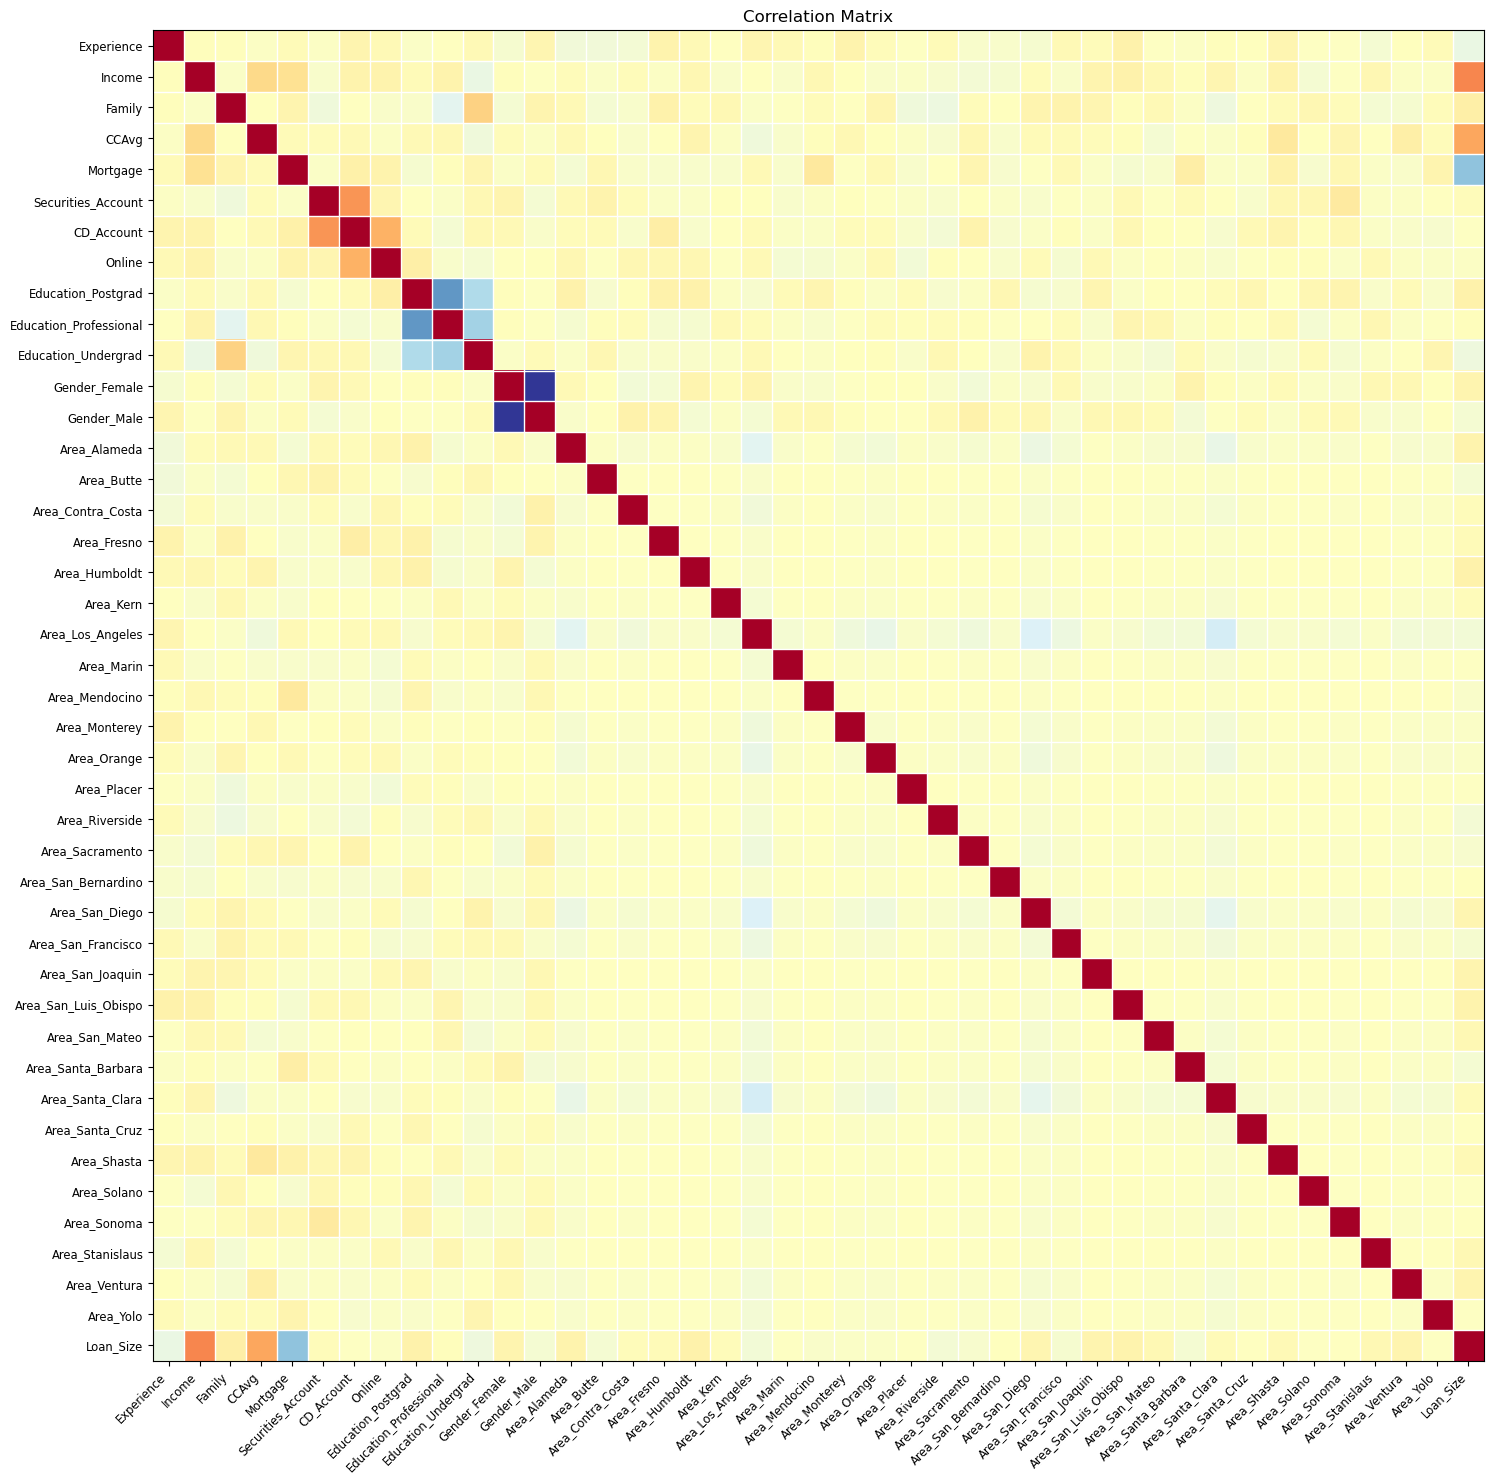

In [39]:
from statsmodels.graphics.correlation import plot_corr

fig = plt.figure(figsize=(15,15));
ax = fig.add_subplot(111);
plot_corr(df_dummies.corr(), xnames = df_dummies.corr().columns, ax = ax);

In [40]:
from statsmodels.formula.api import ols

# Model DataFrame with all of the columns:
dfm = df_dummies.copy()

# The dependent variable:
y_name = 'Loan_Size'

# The independent variable
# (let's first try all of the columns in the model DataFrame)
X_names = [col for col in dfm.columns if col != y_name]

# Build the OLS formula string " y ~ X "
formula_str = y_name+" ~ "+" + ".join(X_names);
print('Formula:\n\t {}'.format(formula_str))

Formula:
	 Loan_Size ~ Experience + Income + Family + CCAvg + Mortgage + Securities_Account + CD_Account + Online + Education_Postgrad + Education_Professional + Education_Undergrad + Gender_Female + Gender_Male + Area_Alameda + Area_Butte + Area_Contra_Costa + Area_Fresno + Area_Humboldt + Area_Kern + Area_Los_Angeles + Area_Marin + Area_Mendocino + Area_Monterey + Area_Orange + Area_Placer + Area_Riverside + Area_Sacramento + Area_San_Bernardino + Area_San_Diego + Area_San_Francisco + Area_San_Joaquin + Area_San_Luis_Obispo + Area_San_Mateo + Area_Santa_Barbara + Area_Santa_Clara + Area_Santa_Cruz + Area_Shasta + Area_Solano + Area_Sonoma + Area_Stanislaus + Area_Ventura + Area_Yolo


In [41]:
# Fit the model using the model DataFrame
model=ols(formula=formula_str, data=dfm)
fitted = model.fit()

# Output the fitted summary
print(fitted.summary())

                            OLS Regression Results                            
Dep. Variable:              Loan_Size   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     38.31
Date:                Mon, 03 Aug 2026   Prob (F-statistic):          9.79e-116
Time:                        17:27:30   Log-Likelihood:                -1388.4
No. Observations:                 471   AIC:                             2857.
Df Residuals:                     431   BIC:                             3023.
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [42]:
df_dummies = pd.get_dummies(df, drop_first=True)

# Again make sure that all the column names have underscores instead of whitespaces
df_dummies.columns = [col.replace(" ", "_") for col in df_dummies.columns]

# Reorder columns with the dependent variable (claim_amount) the last column
column_titles = [col for col in df_dummies.columns if col !=
                 'Loan_Size'] + ['Loan_Size']
df_dummies = df_dummies.reindex(columns=column_titles)

df_dummies.head()

,Experience,Income,Family,CCAvg,Mortgage,Securities_Account,CD_Account,Online,Education_Professional,Education_Undergrad,...,Area_Santa_Barbara,Area_Santa_Clara,Area_Santa_Cruz,Area_Shasta,Area_Solano,Area_Sonoma,Area_Stanislaus,Area_Ventura,Area_Yolo,Loan_Size
Age,,,,,,,,,,,,,,,,,,,,,
26,2,60,2,3.0,132,0,0,0,False,True,...,False,False,False,False,False,False,False,False,False,15
26,0,83,3,3.9,0,0,0,1,False,False,...,False,False,False,False,False,False,False,True,False,30
26,0,129,3,0.7,0,0,0,0,False,False,...,False,False,False,False,False,False,False,False,False,33
26,0,132,3,6.5,0,0,0,0,True,False,...,False,False,False,False,False,False,False,False,False,40
26,2,132,2,2.4,0,0,0,0,True,False,...,False,False,False,False,False,False,False,False,False,35


In [43]:
df_dummies.shape

(471, 40)

In [44]:
# We'll keep the model DataFrame, but only specify the columns we want to fit this time
X_names = [col for col in df_dummies.columns if col != y_name]

# Build the OLS formula string " y ~ X "
formula_str = y_name+' ~ '+'+'.join(X_names)

# Fit the model using the model DataFrame
model = ols(formula=formula_str, data=dfm)
fitted = model.fit()

# Output the fitted summary
print(fitted.summary())

                            OLS Regression Results                            
Dep. Variable:              Loan_Size   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     38.31
Date:                Mon, 03 Aug 2026   Prob (F-statistic):          9.79e-116
Time:                        17:27:30   Log-Likelihood:                -1388.4
No. Observations:                 471   AIC:                             2857.
Df Residuals:                     431   BIC:                             3023.
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [45]:
corrs = df_dummies.corr()['Loan_Size'].sort_values(ascending=False)


In [24]:
from scipy.stats import pearsonr

# Build a dictionary of correlation coefficients and p-values
dict_cp = {}

column_titles = [col for col in corrs.index if col!= 'Loan_Size']

for col in column_titles:
    p_val = round(pearsonr(df_dummies[col], df_dummies['Loan_Size'])[1],6)
    dict_cp[col] = {'Correlation_Coefficient':corrs[col],
                    'P_Value':p_val}

df_cp = pd.DataFrame(dict_cp).T
df_cp_sorted = df_cp.sort_values('P_Value')
df_cp_sorted[df_cp_sorted['P_Value']<0.1]

,Correlation_Coefficient,P_Value
Income,0.522566,0.000000
CCAvg,0.420913,0.000000
Mortgage,-0.496354,0.000000
Experience,-0.131946,0.004124
Education_Undergrad,-0.107046,0.020143
Family,0.097280,0.034806
Area_Los_Angeles,-0.079507,0.084773
Area_Humboldt,0.078831,0.087459
Area_San_Luis_Obispo,0.076123,0.098929


In [46]:
# The dependent variable remains the same:
y_data = df_dummies[y_name]  # y_name = 'Loan_Size'

# Model building – Independent Variable (IV) DataFrame
X_names = list(df_cp[df_cp['P_Value'] < 0.05].index)
X_data = df_dummies[X_names]

In [47]:
# Create the correlation matrix
corr = X_data.corr()

# Find rows and columns where correlation coefficients > 0.9 or <-0.9
corr[np.abs(corr) > 0.9]

,Income,CCAvg,Family,Education_Undergrad,Experience,Mortgage
Income,1.0,NaN,NaN,NaN,NaN,NaN
CCAvg,NaN,1.0,NaN,NaN,NaN,NaN
Family,NaN,NaN,1.0,NaN,NaN,NaN
Education_Undergrad,NaN,NaN,NaN,1.0,NaN,NaN
Experience,NaN,NaN,NaN,NaN,1.0,NaN
Mortgage,NaN,NaN,NaN,NaN,NaN,1.0


In [49]:
# As before, we create the correlation matrix
# and find rows and columns where correlation coefficients > 0.9 or <-0.9
corr = X_data.corr()
r, c = np.where(np.abs(corr) > 0.9)

# We are only interested in the off-diagonal entries:
off_diagonal = np.where(r != c)

# Show the correlation matrix rows and columns where we have highly correlated off-diagonal entries:
corr.iloc[r[off_diagonal], c[off_diagonal]]

""


In [50]:
# Let's take a new subset of our potential independent variables
X_remove = ['Age']
X_corr_names = [col for col in X_names if col not in X_remove]

# Create our new OLS formula based upon our smaller subset
formula_str = y_name+' ~ '+' + '.join(X_corr_names);
print('Formula:\n\t{}'.format(formula_str))

Formula:
	Loan_Size ~ Income + CCAvg + Family + Education_Undergrad + Experience + Mortgage


In [51]:
# Fit the OLS model using the model DataFrame
model=ols(formula=formula_str, data=dfm)
fitted = model.fit()

# Display the fitted summary
print(fitted.summary())

                            OLS Regression Results                            
Dep. Variable:              Loan_Size   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     251.1
Date:                Mon, 03 Aug 2026   Prob (F-statistic):          3.07e-142
Time:                        17:29:33   Log-Likelihood:                -1400.3
No. Observations:                 471   AIC:                             2815.
Df Residuals:                     464   BIC:                             2844.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [52]:
# Separate data into independent (X) and independent (y) variables
X_names = list(df_dummies.columns)
X_names.remove(y_name)
X_data = df_dummies[X_names]
y_data = df_dummies[y_name]

In [53]:
# Normalize data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_data)
X_normalize = pd.DataFrame(X_scaled, columns=X_data.columns)

In [54]:
from sklearn.feature_selection import VarianceThreshold

# Create VarianceThreshold object
selector = VarianceThreshold(threshold=0.03)

# Use the object to apply the threshold on data
selector.fit(X_normalize)

VarianceThreshold(threshold=0.03)

In [55]:
# Get column variances
column_variances = selector.variances_

vars_dict = {}
vars_dict = [{"Variable_Name": c_name, "Variance": c_var}
             for c_name, c_var in zip(X_normalize.columns, column_variances)]
df_vars = pd.DataFrame(vars_dict)
df_vars.sort_values(by='Variance', ascending=False)

,Variable_Name,Variance
10,Gender_Male,0.249945
8,Education_Professional,0.244941
7,Online,0.238504
6,CD_Account,0.204471
16,Area_Los_Angeles,0.179002
9,Education_Undergrad,0.155877
2,Family,0.137325
31,Area_Santa_Clara,0.130968
5,Securities_Account,0.109574
25,Area_San_Diego,0.109574


In [56]:
# Select new columns
X_new = X_normalize[X_normalize.columns[selector.get_support(indices=True)]]

# Save variable names for later
X_var_names = X_new.columns

# View first few entries
X_new.head()

,Experience,Income,Family,CCAvg,Mortgage,Securities_Account,CD_Account,Online,Education_Professional,Education_Undergrad,Gender_Male,Area_Los_Angeles,Area_Monterey,Area_Orange,Area_Sacramento,Area_San_Diego,Area_San_Francisco,Area_Santa_Clara
0,0.04878,0.000000,0.333333,0.30,0.213938,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.00000,0.160839,0.666667,0.39,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.00000,0.482517,0.666667,0.07,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.00000,0.503497,0.666667,0.65,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.04878,0.503497,0.333333,0.24,0.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
X_new.shape

(471, 18)

In [58]:
# Create Variance Threshold objects
selector_1 = VarianceThreshold(threshold=0.05)
selector_2 = VarianceThreshold(threshold=0.1)
selector_3 = VarianceThreshold(threshold=0.15)

In [59]:
selector_1.fit(X_normalize)

VarianceThreshold(threshold=0.05)

In [60]:
selector_2.fit(X_normalize)

VarianceThreshold(threshold=0.1)

In [61]:
selector_3.fit(X_normalize)

VarianceThreshold(threshold=0.15)

In [62]:
# Select subset of columns
X_1 = X_normalize[X_normalize.columns[selector_1.get_support(indices=True)]]
X_2 = X_normalize[X_normalize.columns[selector_2.get_support(indices=True)]]
X_3 = X_normalize[X_normalize.columns[selector_3.get_support(indices=True)]]

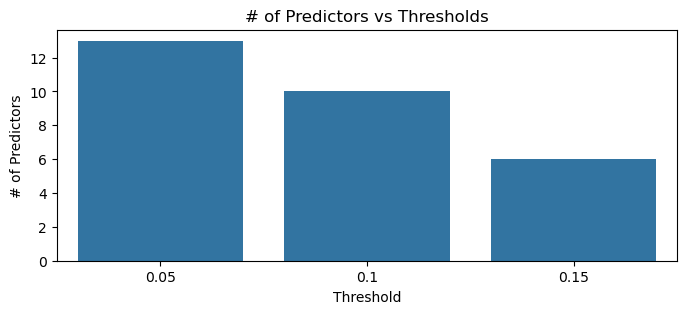

In [63]:
# Create figure and axes
f, ax = plt.subplots(figsize=(8, 3), nrows=1, ncols=1)

# Create list of titles and predictions to use in for loop
subset_preds = [X_1.shape[1], X_2.shape[1], X_3.shape[1]]
thresholds = ['0.05', '0.1', '0.15']

# Plot graph
ax.set_title('# of Predictors vs Thresholds')
ax.set_ylabel('# of Predictors')
ax.set_xlabel('Threshold')
sns.barplot(x=thresholds, y=subset_preds)
plt.show()

In [64]:
# What is our new OLS formula?
formula_str = y_name+' ~ '+' + '.join(X_new.columns)
print('Formula:\n\t{}'.format(formula_str))

Formula:
	Loan_Size ~ Experience + Income + Family + CCAvg + Mortgage + Securities_Account + CD_Account + Online + Education_Professional + Education_Undergrad + Gender_Male + Area_Los_Angeles + Area_Monterey + Area_Orange + Area_Sacramento + Area_San_Diego + Area_San_Francisco + Area_Santa_Clara


In [65]:
# Fit the model using the model DataFrame
model = ols(formula=formula_str, data=df_dummies)
fitted = model.fit()

print(fitted.summary())

                            OLS Regression Results                            
Dep. Variable:              Loan_Size   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     85.32
Date:                Mon, 03 Aug 2026   Prob (F-statistic):          1.08e-132
Time:                        17:33:55   Log-Likelihood:                -1392.1
No. Observations:                 471   AIC:                             2822.
Df Residuals:                     452   BIC:                             2901.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [66]:
# Train-test split the original dataset
X_train, X_test, y_train, y_test = train_test_split(X_data,
                                                    y_data,
                                                    test_size=0.20,
                                                    shuffle=False)

In [67]:
# Get training and testing data for variance threshold model
X_var_train = X_train[X_var_names]
X_var_test = X_test[X_var_names]

In [68]:
# Get training and testing data for correlation threshold model
X_corr_train = X_train[X_corr_names]
X_corr_test = X_test[X_corr_names]

In [69]:
# Instantiate the models
lm = LinearRegression()
lm_corr = LinearRegression()
lm_var = LinearRegression()

In [70]:
# Fit the models
lm.fit(X_train, y_train);
lm_corr.fit(X_corr_train,y_train);
lm_var.fit(X_var_train,y_train);

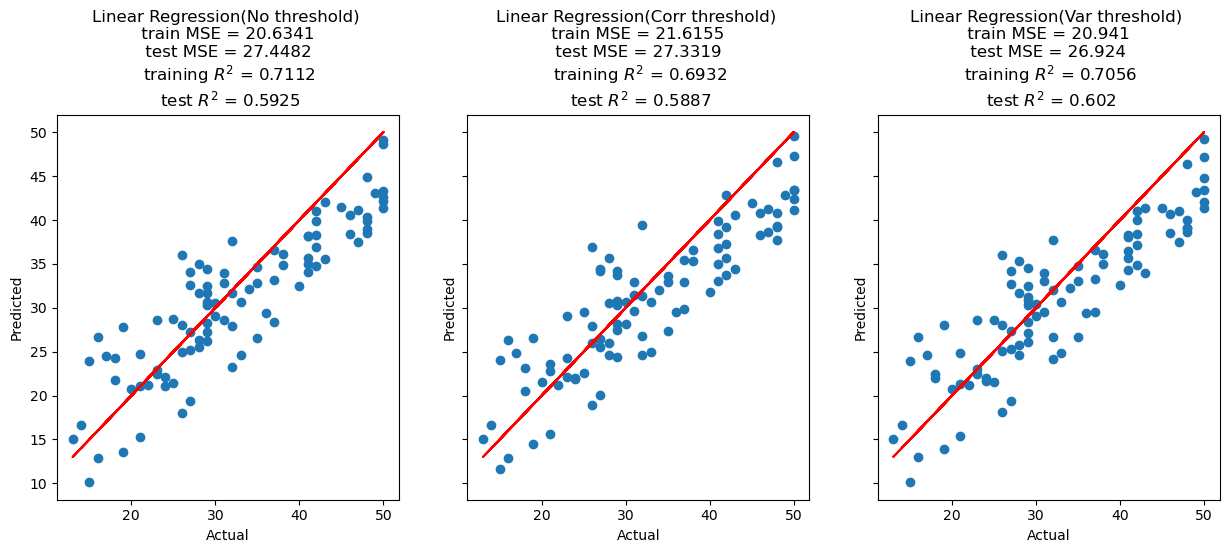

In [71]:
# Create figure and axes
f, ax = plt.subplots(figsize=(15, 5), nrows=1, ncols=3, sharey=True)

# Create list of titles and predictions to use in for loop
train_pred = [lm.predict(X_train),
              lm_corr.predict(X_corr_train),
              lm_var.predict(X_var_train)]
test_pred = [lm.predict(X_test),
             lm_corr.predict(X_corr_test),
             lm_var.predict(X_var_test)]
title = ['No threshold', 'Corr threshold', 'Var threshold']

# Key:
# No threshold – linear regression with all predictive variables
# Corr threshold – linear regression with correlation-thresholded predictive variables
# Var threshold – linear regression with variance-thresholded predictive variables


# Loop through all axes to plot each model's results
for i in range(3):
    test_mse = round(mean_squared_error(test_pred[i], y_test), 4)
    test_r2 = round(r2_score(test_pred[i], y_test), 4)
    train_mse = round(mean_squared_error(train_pred[i], y_train), 4)
    train_r2 = round(r2_score(train_pred[i], y_train), 4)
    title_str = f"Linear Regression({title[i]}) \n train MSE = {train_mse} \n " + \
                f"test MSE = {test_mse} \n training $R^{2}$ = {train_r2} \n " + \
                f"test $R^{2}$ = {test_r2}"
    ax[i].set_title(title_str)
    ax[i].set_xlabel('Actual')
    ax[i].set_ylabel('Predicted')
    ax[i].plot(y_test, y_test, 'r')
    ax[i].scatter(y_test, test_pred[i])